In [ ]:
# -*- coding: utf-8 -*-
"""MainBiochemistry.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/15ToVyykLaAFCu2wZwI_OGrE3wgBvFGA0
"""

# ## **Mount Google Drive**
#
# This cell mounts your Google Drive to Colab, allowing you to access files stored in your Drive.

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ## **Import Libraries**
#
# This cell imports all necessary Python libraries for the notebook.

### IMPORT REQUIRED LIBRARIES ###
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import torch
from transformers import BertTokenizer, BertForSequenceClassification, AdamW
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import spacy
from textblob import TextBlob
import nltk
from collections import Counter

In [ ]:
# ## **Set Global Seed for Reproducibility**
#
# This cell sets a global seed to ensure reproducibility of the experiments.

### SET GLOBAL SEED ###
SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

In [ ]:
# ## **Dataset Loading and Initial Exploration**
#
# This cell loads the dataset from Google Drive and performs initial data exploration.

### DATASET LOADING ###
data_path = '/content/drive/MyDrive/Thesis/Phase 2/Final dataset/Dataset-Biochemistry-binary-final.csv'  # Replace with your file path
data = pd.read_csv(data_path)

### DATA PREPROCESSING ###
# Rename and map labels to integers
data = data.rename(columns={"Question_Option": "text", "Answer": "label"})
data['label'] = data['label'].map({'FALSE': 0, 'TRUE': 1})  # Map string labels to integers
data = data.dropna(subset=['label'])  # Drop rows with missing labels
data['label'] = data['label'].astype(int)

raw_data = pd.read_csv('/content/drive/MyDrive/Thesis/Phase 2/Final dataset/Dataset-Biochemistry-binary-final.csv', header=None)
print(raw_data.head())

import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset with the header
data = pd.read_csv('/content/drive/MyDrive/Thesis/Phase 2/Final dataset/Dataset-Biochemistry-binary-final.csv', header=0)

# Check initial dataset shape and content
print("Initial data shape:", data.shape)
print(data.head())

# Map labels to binary values, handling both string literals and Python booleans
data['Answer'] = data['Answer'].map({True: 1, False: 0, 'TRUE': 1, 'FALSE': 0})

# Check for missing values
print("Missing values in Question_Option:", data['Question_Option'].isnull().sum())
print("Missing values in Answer:", data['Answer'].isnull().sum())

# Drop missing values
data = data.dropna()
print("Data shape after dropping missing values:", data.shape)

# Ensure data is not empty
if data.empty:
    raise ValueError("The dataset is empty after preprocessing.")

                                                   0       1
0                                    Question_Option  Answer
1  Dietary fiber:- Decreases the incidence of con...    TRUE
2  Dietary fiber:- Increases the absorption of ch...   FALSE
3  Dietary fiber:- Decreases the absorption of zinc     TRUE
4  Dietary fiber:- Decreases the incidence of div...    TRUE
Initial data shape: (5116, 2)
                                     Question_Option  Answer
0  Dietary fiber:- Decreases the incidence of con...    True
1  Dietary fiber:- Increases the absorption of ch...   False
2  Dietary fiber:- Decreases the absorption of zinc     True
3  Dietary fiber:- Decreases the incidence of div...    True
4  Dietary fiber:- Helps in better control of dia...    True
Missing values in Question_Option: 0
Missing values in Answer: 0
Data shape after dropping missing values: (5116, 2)


In [ ]:
# ## **Data Splitting**
#
# This cell splits the dataset into training, validation, and test sets.

### DATA SPLITTING ###
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    data['Question_Option'].tolist(),
    data['Answer'].tolist(),
    test_size=0.2,  # 20% for temporary set
    random_state=SEED
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,  # 10% validation, 10% test
    random_state=SEED
)

# Further split the temporary set into validation and test sets
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,  # 10% validation, 10% test
    random_state=42
)

# Print split sizes
print(f"Training set: {len(train_texts)}")
print(f"Validation set: {len(val_texts)}")
print(f"Test set: {len(test_texts)}")

data.isnull()
data.isnull().sum()

data.head(10)

data.columns

# Calculate dataset sizes from final splits
train_size = len(train_texts)
val_size   = len(val_texts)
test_size  = len(test_texts)
total_size = train_size + val_size + test_size

# Print dataset sizes and proportions
print(f"Total dataset size: {total_size}")
print(f"Training set size: {train_size} ({(train_size / total_size) * 100:.2f}%)")
print(f"Validation set size: {val_size} ({(val_size / total_size) * 100:.2f}%)")
print(f"Test set size: {test_size} ({(test_size / total_size) * 100:.2f}%)")

Training set: 4092
Validation set: 512
Test set: 512
Total dataset size: 5116
Training set size: 4092 (79.98%)
Validation set size: 512 (10.01%)
Test set size: 512 (10.01%)


In [ ]:
# ## **Tokenization and DataLoader Creation**
#
# This cell handles tokenization of text data and creates DataLoaders for training, validation, and testing.

### TOKENIZATION AND DATALOADER CREATION ###
model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Tokenization function
def tokenize_data(texts, labels):
    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )
    return inputs, torch.tensor(labels)

train_inputs, train_labels = tokenize_data(train_texts, train_labels)
val_inputs, val_labels = tokenize_data(val_texts, val_labels)
test_inputs, test_labels = tokenize_data(test_texts, test_labels)
# Dataset class and DataLoader
class TextDataset(Dataset):
    def __init__(self, inputs, labels):
        self.inputs = inputs
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {key: val[idx] for key, val in self.inputs.items()}, self.labels[idx]

train_loader = DataLoader(TextDataset(train_inputs, train_labels), batch_size=16, shuffle=True)
val_loader = DataLoader(TextDataset(val_inputs, val_labels), batch_size=16)
test_loader = DataLoader(TextDataset(test_inputs, test_labels), batch_size=16)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
# ## **Model Training**
#
# This cell defines the training process and trains the BERT model.

### TRAINING ###
optimizer = AdamW(model.parameters(), lr=1e-5)

def train_model(model, train_loader, val_loader, epochs=4):
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            inputs, labels = batch
            inputs = {key: val.to(device) for key, val in inputs.items()}
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(**inputs, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_losses.append(train_loss / len(train_loader))

        # Validation
        model.eval()
        val_loss = 0
        val_preds, val_targets = [], []
        with torch.no_grad():
            for batch in val_loader:
                inputs, labels = batch
                inputs = {key: val.to(device) for key, val in inputs.items()}
                labels = labels.to(device)

                outputs = model(**inputs, labels=labels)
                val_loss += outputs.loss.item()
                preds = torch.argmax(outputs.logits, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(labels.cpu().numpy())

        val_losses.append(val_loss / len(val_loader))

        print(f"Epoch {epoch + 1}/{epochs}")
        print("Validation Report:", classification_report(val_targets, val_preds))

    return train_losses, val_losses

train_losses, val_losses = train_model(model, train_loader, val_loader)

/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1/4
Validation Report:               precision    recall  f1-score   support

           0       0.56      0.32      0.40       234
           1       0.58      0.79      0.67       278

    accuracy                           0.57       512
   macro avg       0.57      0.55      0.54       512
weighted avg       0.57      0.57      0.55       512

Epoch 2/4
Validation Report:               precision    recall  f1-score   support

           0       0.50      0.91      0.65       234
           1       0.75      0.24      0.37       278

    accuracy                           0.54       512
   macro avg       0.63      0.57      0.51       512
weighted avg       0.64      0.54      0.49       512

Epoch 3/4
Validation Report:               precision    recall  f1-score   support

           0       0.62      0.50      0.56       234
           1       0.64      0.74      0.69       278

    accuracy                           0.63       512
   macro avg       0.63      0.62      0.

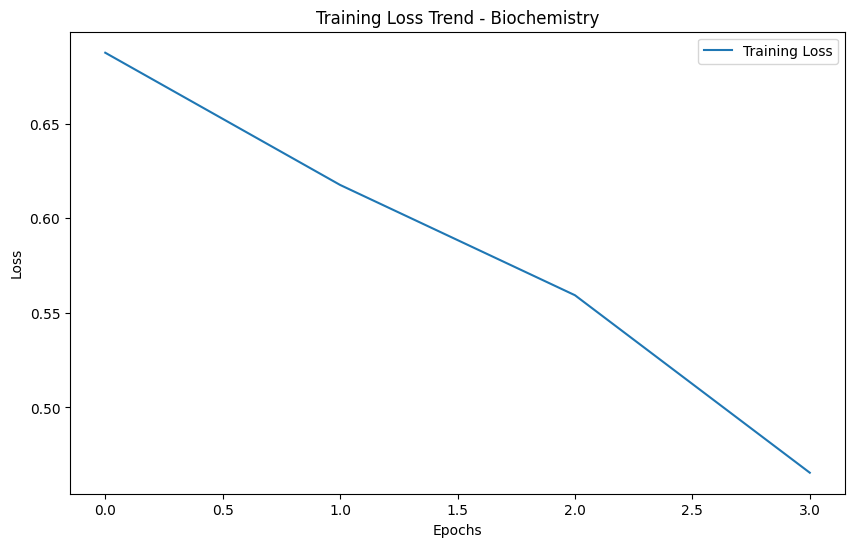

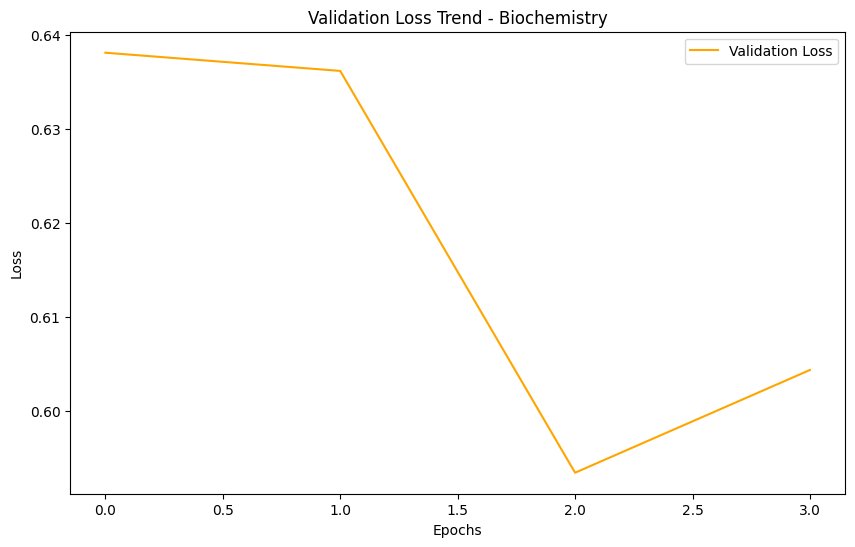

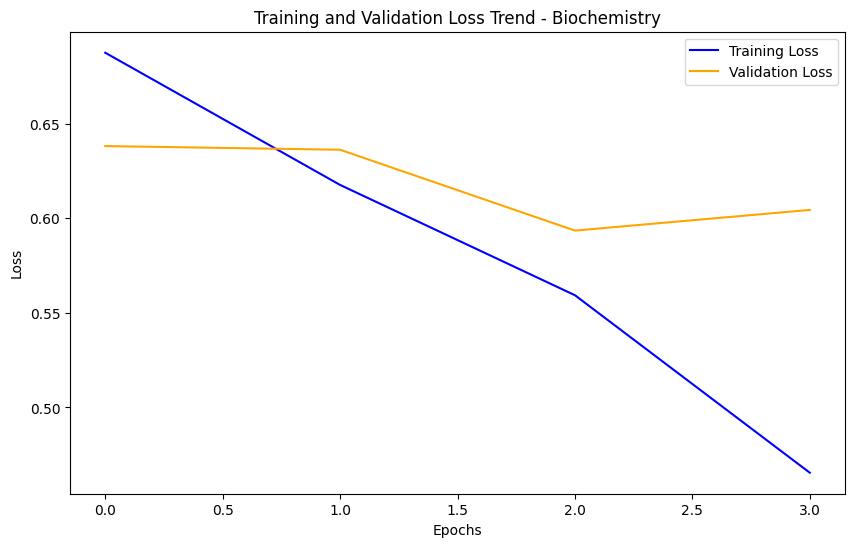

In [ ]:
# ## **Training and Validation Loss Visualization**
#
# This cell visualizes the training and validation loss curves.

# Train Loss Plot
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Trend - Biochemistry")
plt.legend()
plt.show()

### VALIDATION VISUALIZATION ###
plt.figure(figsize=(10, 6))
plt.plot(val_losses, label="Validation Loss", color="orange")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Validation Loss Trend - Biochemistry")
plt.legend()
plt.show()

# Combined Loss Plot
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="orange")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Trend - Biochemistry")
plt.legend()
plt.show()

In [ ]:
# ## **Model Testing and Evaluation**
#
# This cell evaluates the trained model on the test set and reports performance metrics.

### TESTING ###
def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            inputs, labels = batch
            inputs = {key: val.to(device) for key, val in inputs.items()}
            labels = labels.to(device)

            outputs = model(**inputs)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, output_dict=True)
    conf_matrix = confusion_matrix(all_labels, all_preds)
    return accuracy, report, conf_matrix

accuracy, report, conf_matrix = evaluate_model(model, test_loader)

# Test Results
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("Test Classification Report:")
print(report)

Test Accuracy: 63.87%
Test Classification Report:
{'0': {'precision': 0.5951417004048583, 'recall': 0.6336206896551724, 'f1-score': 0.6137787056367432, 'support': 232.0}, '1': {'precision': 0.6792452830188679, 'recall': 0.6428571428571429, 'f1-score': 0.6605504587155964, 'support': 280.0}, 'accuracy': 0.638671875, 'macro avg': {'precision': 0.6371934917118631, 'recall': 0.6382389162561577, 'f1-score': 0.6371645821761698, 'support': 512.0}, 'weighted avg': {'precision': 0.6411358471468948, 'recall': 0.638671875, 'f1-score': 0.639357008101741, 'support': 512.0}}


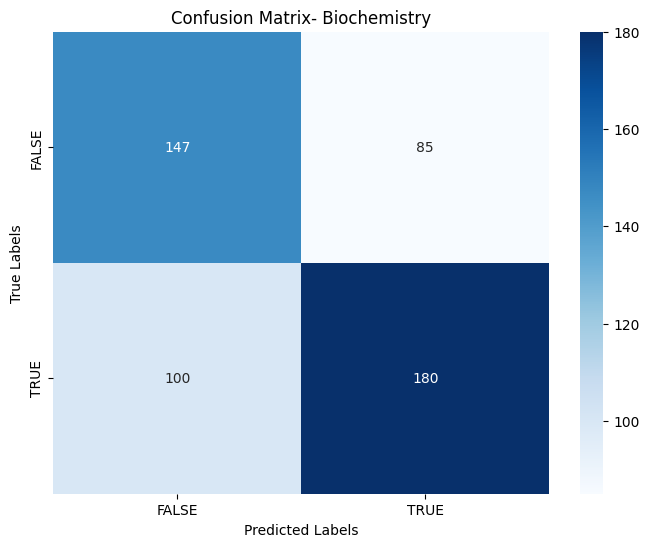

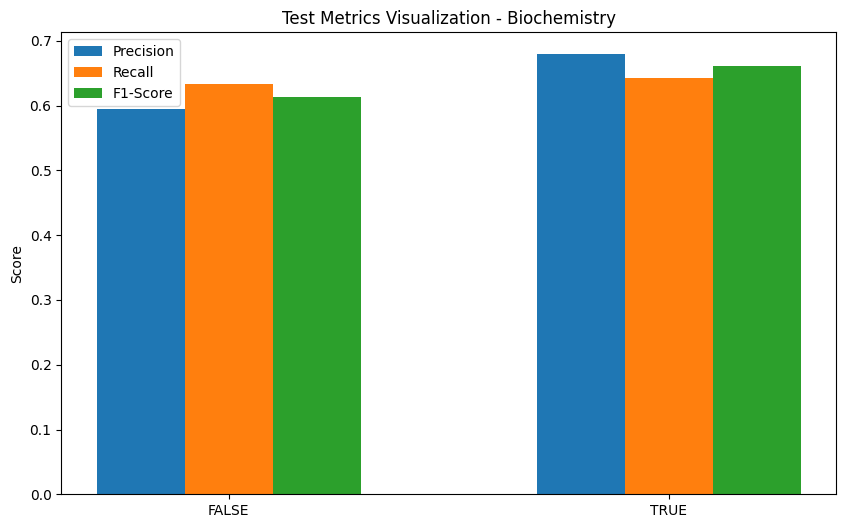

In [ ]:
# ## **Test Results Visualization**
#
# This cell visualizes the test results, including confusion matrix and metrics bar chart.

# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=["FALSE", "TRUE"], yticklabels=["FALSE", "TRUE"])
plt.title("Confusion Matrix- Biochemistry")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Metrics Visualization
labels = ["FALSE", "TRUE"]
precision = [report[str(i)]["precision"] for i in range(2)]
recall = [report[str(i)]["recall"] for i in range(2)]
f1_score = [report[str(i)]["f1-score"] for i in range(2)]

x = np.arange(len(labels))
width = 0.2

plt.figure(figsize=(10, 6))
plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1_score, width, label="F1-Score")
plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Test Metrics Visualization - Biochemistry")
plt.legend()
plt.show()

In [ ]:
# ## **Label Distribution Analysis**
#
# This cell analyzes and prints the distribution of TRUE/FALSE labels in the dataset.

# After mapping TRUE/FALSE to 1/0
binary_counts = data['Answer'].value_counts()

print("Counts of 1 (TRUE) and 0 (FALSE):")
print(binary_counts)

Counts of 1 (TRUE) and 0 (FALSE):
Answer
1    2602
0    2514
Name: count, dtype: int64


In [ ]:
# ## **Exploratory Data Analysis (EDA) - Text Feature Extraction**
#
# This section performs Exploratory Data Analysis (EDA) on the text data using TF-IDF, Sentiment Analysis, and Named Entity Recognition.

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.sentiment import SentimentIntensityAnalyzer
import spacy
import nltk

# Load dataset with correct separator
file_path = '/content/drive/MyDrive/Thesis/Phase 2/Final dataset/Dataset-Biochemistry-binary-final.csv' # Replace with the correct file path
df = pd.read_csv(file_path, sep=",")  # Adjust the separator

# Check the dataset structure
print("Dataset Overview")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"Columns: {df.columns.tolist()}")
print("Sample Data:")
print(df.head())

# Ensure column names are correctly separated
if 'Question_Option' not in df.columns:
    df[['Question_Option', 'Answer']] = df.iloc[:, 0].str.split(",", expand=True)
    df.drop(columns=[df.columns[0]], inplace=True)

# Confirm changes
print("\nCleaned Data:")
print(df.head())

# Data Preprocessing
df['Question_Option'] = df['Question_Option'].str.strip()

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['Question_Option'])
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print("\nTF-IDF Analysis")
print("TF-IDF Feature Names (first 10):", tfidf_feature_names[:10])
print("TF-IDF Shape:", tfidf_matrix.shape)

# Calculate cosine similarity between TF-IDF vectors
cos_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("\nCosine Similarity Matrix (first 5 rows):")
print(cos_sim[:5, :5])

# Sentiment Analysis using VADER
print("\nSentiment Analysis")
nltk.download("vader_lexicon")
sia = SentimentIntensityAnalyzer()

df['Sentiment'] = df['Question_Option'].apply(lambda x: sia.polarity_scores(x)['compound'])
print("Sample Sentiment Scores:")
print(df[['Question_Option', 'Sentiment']].head())

# Named Entity Recognition (NER) and POS tagging with spaCy
print("\nNamed Entity Recognition (NER) and POS Tagging")
nlp = spacy.load("en_core_web_sm")

def extract_ner_pos(text):
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    pos_tags = [(token.text, token.pos_) for token in doc]
    return entities, pos_tags

df['NER_POS'] = df['Question_Option'].apply(extract_ner_pos)

# Display NER and POS Tags for the first 5 rows
for i, row in df.head().iterrows():
    print(f"\nQuestion: {row['Question_Option']}")
    print("Named Entities:", row['NER_POS'][0])
    print("POS Tags:", row['NER_POS'][1])

# Save processed data to a new CSV for analysis
output_file = "processed_dataset.csv"
df.to_csv(output_file, index=False)
print(f"\nProcessed data saved to {output_file}")

Dataset Overview
Number of rows: 5116
Number of columns: 2
Columns: ['Question_Option', 'Answer']
Sample Data:
                                     Question_Option  Answer
0  Dietary fiber:- Decreases the incidence of con...    True
1  Dietary fiber:- Increases the absorption of ch...   False
2  Dietary fiber:- Decreases the absorption of zinc     True
3  Dietary fiber:- Decreases the incidence of div...    True
4  Dietary fiber:- Helps in better control of dia...    True

Cleaned Data:
                                     Question_Option  Answer
0  Dietary fiber:- Decreases the incidence of con...    True
1  Dietary fiber:- Increases the absorption of ch...   False
2  Dietary fiber:- Decreases the absorption of zinc     True
3  Dietary fiber:- Decreases the incidence of div...    True
4  Dietary fiber:- Helps in better control of dia...    True

TF-IDF Analysis
TF-IDF Feature Names (first 10): ['0001' '10' '100' '1000' '1000ml' '103' '105' '11' '1100' '131i']
TF-IDF Shape: (5116, 2769

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Sample Sentiment Scores:
                                     Question_Option  Sentiment
0  Dietary fiber:- Decreases the incidence of con...     0.0000
1  Dietary fiber:- Increases the absorption of ch...     0.0000
2   Dietary fiber:- Decreases the absorption of zinc     0.0000
3  Dietary fiber:- Decreases the incidence of div...     0.0000
4  Dietary fiber:- Helps in better control of dia...     0.6705

Named Entity Recognition (NER) and POS Tagging

Question: Dietary fiber:- Decreases the incidence of constipation
Named Entities: []
POS Tags: [('Dietary', 'ADJ'), ('fiber:-', 'PUNCT'), ('Decreases', 'VERB'), ('the', 'DET'), ('incidence', 'NOUN'), ('of', 'ADP'), ('constipation', 'NOUN')]

Question: Dietary fiber:- Increases the absorption of cholesterol
Named Entities: []
POS Tags: [('Dietary', 'ADJ'), ('fiber:-', 'PUNCT'), ('Increases', 'VERB'), ('the', 'DET'), ('absorption', 'NOUN'), ('of', 'ADP'), ('cholesterol', 'NOUN')]

Question: Dietary fiber:- Decreases the absorption of zinc

In [ ]:
# ## **EDA - Advanced Text Analysis (TF-IDF, Sentiment, NER, POS)**
#
# This cell continues the EDA with more in-depth text analysis using TF-IDF, sentiment, NER, and POS tagging.

### ADDITIONAL REQUIRED LIBRARIES ###
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import spacy
from textblob import TextBlob

### LOAD SPACY MODEL ###
nlp = spacy.load("en_core_web_sm")  # Ensure you have downloaded the model: python -m spacy download en_core_web_sm

### TF-IDF CALCULATION ###
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(data['Question_Option'])
tfidf_features = tfidf_vectorizer.get_feature_names_out()

# Example: Show top TF-IDF terms for a specific question
def display_tfidf_for_question(index):
    print(f"Top TF-IDF terms for question: {data['Question_Option'][index]}")
    feature_index = tfidf_matrix[index].nonzero()[1]
    tfidf_scores = zip(feature_index, [tfidf_matrix[index, x] for x in feature_index])
    for w, s in sorted(tfidf_scores, key=lambda x: -x[1])[:5]:
        print(f"Word: {tfidf_features[w]}, Score: {s:.4f}")

display_tfidf_for_question(0)  # Display for the first question

### SENTIMENT ANALYSIS ###
data['Sentiment'] = data['Question_Option'].apply(lambda x: TextBlob(x).sentiment.polarity)
print("Sample Sentiments:")
print(data[['Question_Option', 'Sentiment']].head())

### NAMED ENTITY RECOGNITION (NER) ###
def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

data['Entities'] = data['Question_Option'].apply(extract_entities)
print("Sample Named Entities:")
print(data[['Question_Option', 'Entities']].head())

### PART-OF-SPEECH (POS) TAGGING ###
def pos_tagging(text):
    doc = nlp(text)
    return [(token.text, token.pos_) for token in doc]

data['POS Tags'] = data['Question_Option'].apply(pos_tagging)
print("Sample POS Tags:")
print(data[['Question_Option', 'POS Tags']].head())

### COSINE SIMILARITY ###
# Calculate similarity between first two questions
cosine_sim = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix)
print("Cosine Similarity with the first question:")
print(cosine_sim[0][:5])  # Show similarity scores for the first 5 questions

/usr/local/lib/python3.11/dist-packages/spacy/util.py:1740: UserWarning: [W111] Jupyter notebook detected: if using `prefer_gpu()` or `require_gpu()`, include it in the same cell right before `spacy.load()` to ensure that the model is loaded on the correct device. More information: http://spacy.io/usage/v3#jupyter-notebook-gpu
  warnings.warn(Warnings.W111)


Top TF-IDF terms for question: Dietary fiber:- Decreases the incidence of constipation  
Word: constipation, Score: 0.5144
Word: incidence, Score: 0.4512
Word: decreases, Score: 0.4416
Word: fiber, Score: 0.3867
Word: dietary, Score: 0.3610
Sample Sentiments:
                                     Question_Option  Sentiment
0  Dietary fiber:- Decreases the incidence of con...        0.0
1  Dietary fiber:- Increases the absorption of ch...        0.0
2  Dietary fiber:- Decreases the absorption of zinc         0.0
3  Dietary fiber:- Decreases the incidence of div...        0.0
4  Dietary fiber:- Helps in better control of dia...        0.5
Sample Named Entities:
                                     Question_Option Entities
0  Dietary fiber:- Decreases the incidence of con...       []
1  Dietary fiber:- Increases the absorption of ch...       []
2  Dietary fiber:- Decreases the absorption of zinc        []
3  Dietary fiber:- Decreases the incidence of div...       []
4  Dietary fiber:- Help

In [ ]:
# ## **EDA - Dataset Summary Statistics**
#
# This cell calculates and prints summary statistics of the dataset.

### DATASET CHARACTERISTICS ###
def dataset_summary(data):
    print("Dataset Characteristics:")
    print(f"Total questions: {data.shape[0]}")
    print(f"Unique questions: {data['Question_Option'].nunique()}")
    print(f"Number of TRUE labels: {data['Answer'].sum()}")
    print(f"Number of FALSE labels: {len(data) - data['Answer'].sum()}")
    print(f"Average sentiment polarity: {data['Sentiment'].mean():.4f}")
    print(f"Top named entities: {pd.Series([ent for ents in data['Entities'] for ent in ents]).value_counts().head()}")

dataset_summary(data)

Dataset Characteristics:
Total questions: 5116
Unique questions: 4564
Number of TRUE labels: 2602
Number of FALSE labels: 2514
Average sentiment polarity: 0.0051
Top named entities: (Plasma, PERSON)      70
(Cholesterol, ORG)    50
(BMR, ORG)            43
(Ammonia, GPE)        42
(Trace, ORG)          41
Name: count, dtype: int64


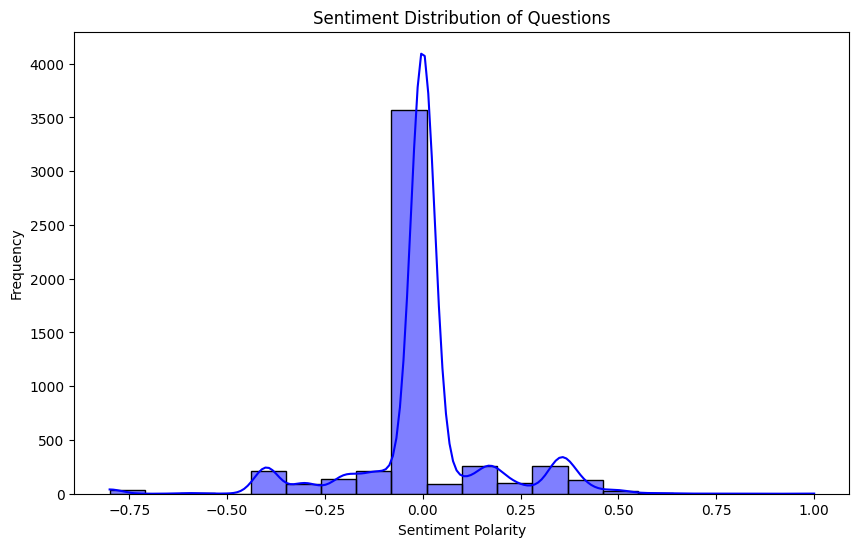

<ipython-input-16-3dd39318fc22>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Answer', data=data, palette='viridis')


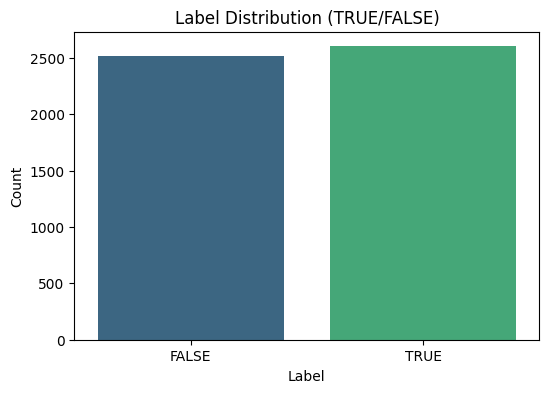

In [ ]:
# ## **EDA - Visualizations (Sentiment and Label Distribution)**
#
# This cell generates visualizations for sentiment distribution and label distribution.

### VISUALIZATION ###
import seaborn as sns
import matplotlib.pyplot as plt

# Sentiment Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['Sentiment'], bins=20, kde=True, color='blue')
plt.title("Sentiment Distribution of Questions")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Frequency")
plt.show()

# Label Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Answer', data=data, palette='viridis')
plt.title("Label Distribution (TRUE/FALSE)")
plt.xticks(ticks=[0, 1], labels=["FALSE", "TRUE"])
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [ ]:
# ## **EDA - Comprehensive Text Analysis and Statistics**
#
# This cell performs a comprehensive text analysis, including text length statistics, TF-IDF analysis, NER counts, POS tag counts, and sentiment analysis.

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy
from collections import Counter

# Load dataset
data_path = '/content/drive/MyDrive/Thesis/Phase 2/Final dataset/Dataset-Biochemistry-binary-final.csv'
data = pd.read_csv(data_path)

# Map labels to binary values
data['Answer'] = data['Answer'].map({'TRUE': 1, 'FALSE': 0})

# General Dataset Characteristics
print("Dataset Shape:", data.shape)
print("\nColumn Names:", data.columns)
print("\nNumber of Unique Questions:", data['Question_Option'].nunique())
print("\nLabel Distribution:")
print(data['Answer'].value_counts())

# Text Length Analysis
data['text_length'] = data['Question_Option'].apply(len)
print("\nText Length Statistics:")
print(data['text_length'].describe())

# TF-IDF Analysis
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(data['Question_Option'])
print("\nVocabulary Size (TF-IDF):", len(tfidf_vectorizer.vocabulary_))
print("Top 10 Words by TF-IDF Scores:")
tfidf_scores = zip(tfidf_vectorizer.get_feature_names_out(), tfidf_matrix.sum(axis=0).tolist()[0])
top_tfidf_words = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)[:10]
for word, score in top_tfidf_words:
    print(f"{word}: {score:.4f}")

# Named Entity Recognition (NER) with spaCy
nlp = spacy.load("en_core_web_sm")
ner_entities = []
for text in data['Question_Option']:
    doc = nlp(text)
    for ent in doc.ents:
        ner_entities.append(ent.label_)

entity_counts = Counter(ner_entities)
print("\nNamed Entity Counts:")
for entity, count in entity_counts.items():
    print(f"{entity}: {count}")

# Sentiment Analysis (Using polarity from spaCy as a placeholder for advanced tools)
print("\nSentiment Analysis (Polarity):")
data['polarity'] = data['Question_Option'].apply(lambda x: nlp(x)._.polarity if nlp(x).has_extension("_polarity") else "N/A")
print(data['polarity'].value_counts())

# Part-of-Speech (POS) Tagging
pos_counts = Counter()
for text in data['Question_Option']:
    doc = nlp(text)
    pos_counts.update([token.pos_ for token in doc])

print("\nPart-of-Speech Tag Counts:")
for pos, count in pos_counts.most_common():
    print(f"{pos}: {count}")

Dataset Shape: (5116, 2)

Column Names: Index(['Question_Option', 'Answer'], dtype='object')

Number of Unique Questions: 4564

Label Distribution:
Series([], Name: count, dtype: int64)

Text Length Statistics:
count    5116.000000
mean       51.048671
std        15.416707
min         8.000000
25%        41.000000
50%        49.000000
75%        58.000000
max       144.000000
Name: text_length, dtype: float64

Vocabulary Size (TF-IDF): 2769
Top 10 Words by TF-IDF Scores:
are: 258.5323
of: 251.2597
is: 217.2616
in: 194.7505
the: 183.3153
acid: 119.3369
following: 118.6509
by: 104.6288
true: 90.0234
include: 86.4251


/usr/local/lib/python3.11/dist-packages/spacy/util.py:1740: UserWarning: [W111] Jupyter notebook detected: if using `prefer_gpu()` or `require_gpu()`, include it in the same cell right before `spacy.load()` to ensure that the model is loaded on the correct device. More information: http://spacy.io/usage/v3#jupyter-notebook-gpu
  warnings.warn(Warnings.W111)



Named Entity Counts:
WORK_OF_ART: 6
PERSON: 588
PRODUCT: 22
ORG: 969
QUANTITY: 12
GPE: 170
CARDINAL: 173
PERCENT: 15
LOC: 2
FAC: 16
LAW: 5
NORP: 89
LANGUAGE: 1
ORDINAL: 9
DATE: 8
TIME: 7

Sentiment Analysis (Polarity):
polarity
N/A    5116
Name: count, dtype: int64

Part-of-Speech Tag Counts:
NOUN: 14221
PUNCT: 5451
ADJ: 4810
ADP: 4547
VERB: 4186
PROPN: 3467
AUX: 3281
DET: 1603
PRON: 349
NUM: 323
X: 318
ADV: 307
PART: 219
CCONJ: 137
SCONJ: 91
SYM: 66
SPACE: 65
INTJ: 3


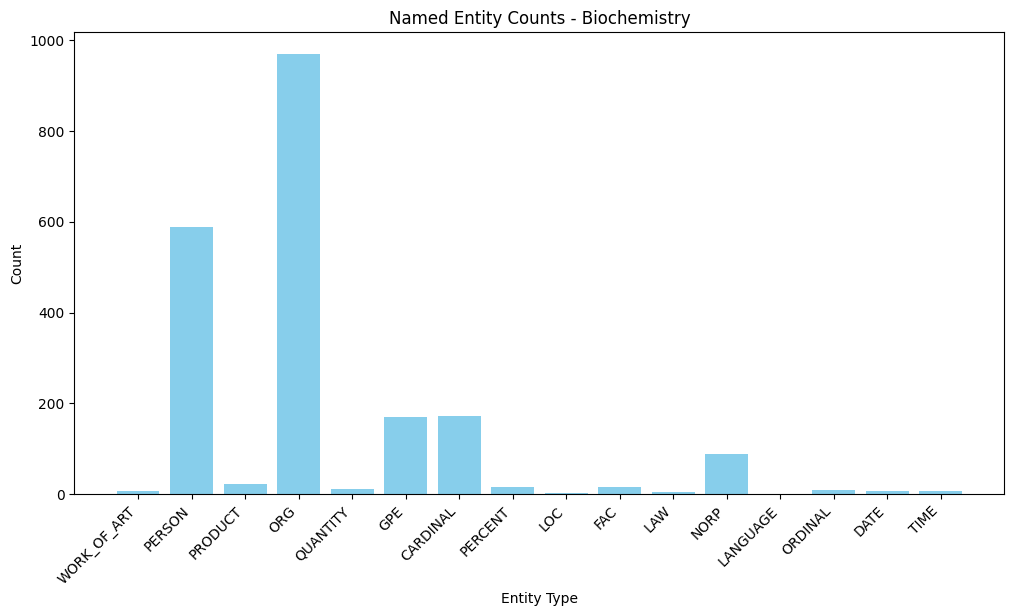

<ipython-input-19-9e62f7d2db2f>:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=tfidf_scores['Word'], x=tfidf_scores['Score'], palette='cool')


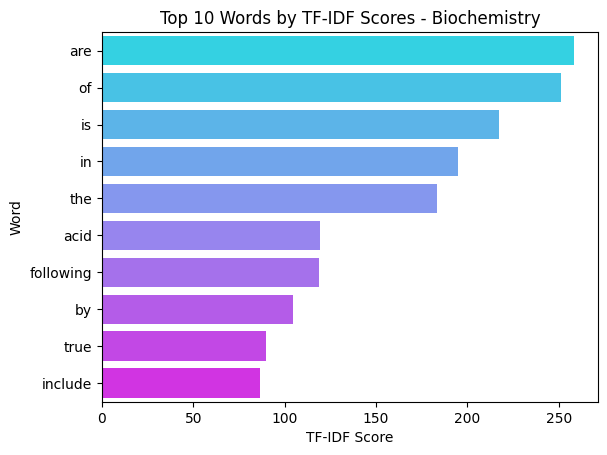

<ipython-input-19-9e62f7d2db2f>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pos_counts['POS Tag'], y=pos_counts['Count'], palette='cubehelix')


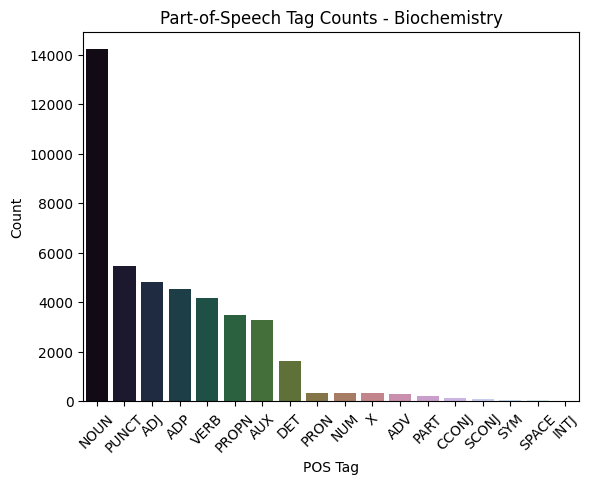

In [ ]:
# ## **EDA - Visualizations (NER, TF-IDF, POS Counts)**
#
# This cell generates bar plots to visualize Named Entity Counts, Top TF-IDF Words, and Part-of-Speech Tag Counts.

import matplotlib.pyplot as plt

# Named Entity Counts
entity_counts = {
    "WORK_OF_ART": 6, "PERSON": 588, "PRODUCT": 22, "ORG": 969, "QUANTITY": 12,
    "GPE": 170, "CARDINAL": 173, "PERCENT": 15, "LOC": 2, "FAC": 16,
    "LAW": 5, "NORP": 89, "LANGUAGE": 1, "ORDINAL": 9, "DATE": 8, "TIME": 7
}

# Plotting
plt.figure(figsize=(12, 6))
plt.bar(entity_counts.keys(), entity_counts.values(), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title("Named Entity Counts - Biochemistry")
plt.ylabel("Count")
plt.xlabel("Entity Type")
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

# Updated TF-IDF scores
tfidf_scores = {
    "Word": ['are', 'of', 'is', 'in', 'the', 'acid', 'following', 'by', 'true', 'include'],
    "Score": [258.5323, 251.2597, 217.2616, 194.7505, 183.3153, 119.3369, 118.6509, 104.6288, 90.0234, 86.4251]
}

# Create the bar plot
sns.barplot(y=tfidf_scores['Word'], x=tfidf_scores['Score'], palette='cool')
plt.title("Top 10 Words by TF-IDF Scores - Biochemistry")
plt.xlabel("TF-IDF Score")
plt.ylabel("Word")
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

# Updated part-of-speech tag counts
pos_counts = {
    "POS Tag": ['NOUN', 'PUNCT', 'ADJ', 'ADP', 'VERB', 'PROPN', 'AUX',
                'DET', 'PRON', 'NUM', 'X', 'ADV', 'PART', 'CCONJ', 'SCONJ',
                'SYM', 'SPACE', 'INTJ'],
    "Count": [14221, 5451, 4810, 4547, 4186, 3467, 3281, 1603, 349,
              323, 318, 307, 219, 137, 91, 66, 65, 3]
}

# Create the bar plot
sns.barplot(x=pos_counts['POS Tag'], y=pos_counts['Count'], palette='cubehelix')
plt.title("Part-of-Speech Tag Counts - Biochemistry")
plt.xlabel("POS Tag")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

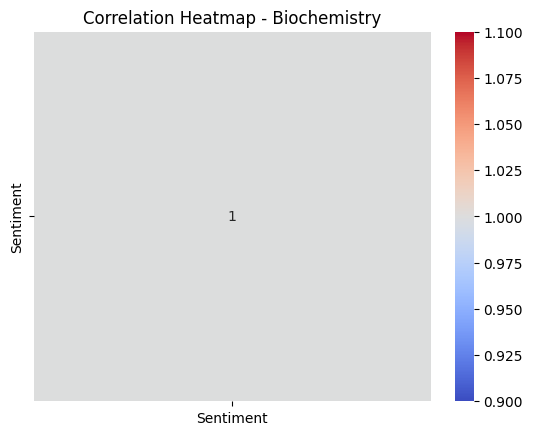

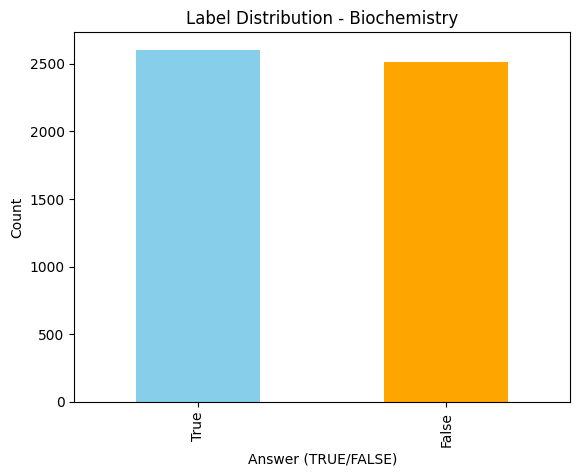

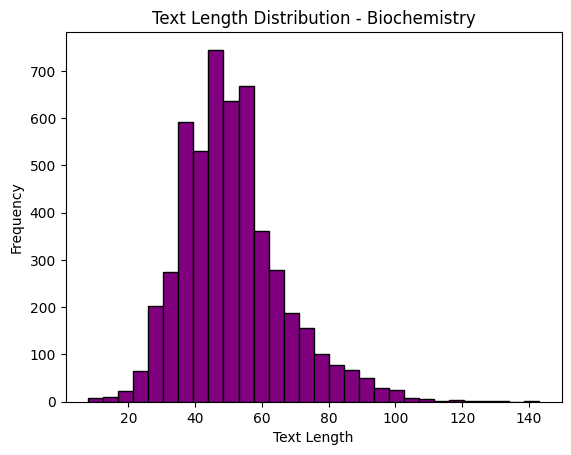

In [ ]:
# ## **EDA - Correlation Heatmap and Distribution Plots**
#
# This cell generates a correlation heatmap for numeric data and example distribution plots for labels and text lengths.

# Filter numeric columns
numeric_data = df.select_dtypes(include='number')

# Plot heatmap
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap - Biochemistry")
plt.show()

import matplotlib.pyplot as plt

# Example bar chart for label distribution
label_counts = df['Answer'].value_counts()
label_counts.plot(kind='bar', color=['skyblue', 'orange'])
plt.title("Label Distribution - Biochemistry")
plt.xlabel("Answer (TRUE/FALSE)")
plt.ylabel("Count")
plt.show()

# Example histogram for text lengths
df['text_length'] = df['Question_Option'].str.len()  # Calculate text lengths
df['text_length'].plot(kind='hist', bins=30, color='purple', edgecolor='black')
plt.title("Text Length Distribution - Biochemistry")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# ## **EDA - Interactive Label Distribution (Plotly)**
#
# This cell generates an interactive bar chart for label distribution using Plotly.

import plotly.express as px

# Example interactive bar chart
fig = px.bar(label_counts, x=label_counts.index, y=label_counts.values,
             title="Interactive Label Distribution - Biochemistry",
             labels={'x': "Answer (TRUE/FALSE)", 'y': "Count"})
fig.show()